In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,classification_report
from xgboost import XGBClassifier
import datetime as dt
from imblearn.over_sampling import SMOTE
np.random.seed(42)

In [71]:
df=pd.read_csv('merged_fraud_detection_data.csv')

In [72]:
df.head()

,transaction_id,user_id,amount,currency,merchant_id,timestamp,device_id,device_type,ip_address,country,chargeback_date,chargeback_amount,is_fraud
0,TXN100000,USER4174,59.63,EUR,M322,2024-04-07 14:22:06,D1855,tablet,192.168.191.91,IN,NaN,NaN,0.0
1,TXN100001,USER4507,74.28,EUR,M147,2024-03-12 01:37:39,D2371,mobile,192.168.38.95,US,NaN,NaN,0.0
2,TXN100002,USER1860,130.20,USD,M181,2024-01-22 08:04:34,D2802,desktop,192.168.66.194,US,NaN,NaN,0.0
3,TXN100003,USER2294,3.84,KES,M277,2024-01-30 13:02:58,D2786,mobile,192.168.167.230,IN,NaN,NaN,0.0
4,TXN100004,USER2130,70.59,KES,M334,2024-02-22 15:37:38,D1693,desktop,192.168.212.160,IN,NaN,NaN,0.0


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     50000 non-null  object 
 1   user_id            50000 non-null  object 
 2   amount             50000 non-null  float64
 3   currency           50000 non-null  object 
 4   merchant_id        50000 non-null  object 
 5   timestamp          50000 non-null  object 
 6   device_id          50000 non-null  object 
 7   device_type        50000 non-null  object 
 8   ip_address         50000 non-null  object 
 9   country            50000 non-null  object 
 10  chargeback_date    1500 non-null   object 
 11  chargeback_amount  1500 non-null   float64
 12  is_fraud           48495 non-null  float64
dtypes: float64(3), object(10)
memory usage: 5.0+ MB


In [74]:
df.describe()

,amount,chargeback_amount,is_fraud
count,50000.000000,1500.000000,48495.000000
mean,198.594993,278.002480,0.051304
std,197.870263,131.944896,0.220620
min,0.000000,50.150000,0.000000
25%,57.660000,163.600000,0.000000
50%,138.135000,277.900000,0.000000
75%,276.475000,390.995000,0.000000
max,2097.720000,499.680000,1.000000


In [75]:
df_copy=df.copy()

In [76]:
df_copy['chargeback_date']=df_copy['chargeback_date'].fillna(0)

In [77]:
df_copy['chargeback_amount']=df_copy['chargeback_amount'].fillna(0)

In [78]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     50000 non-null  object 
 1   user_id            50000 non-null  object 
 2   amount             50000 non-null  float64
 3   currency           50000 non-null  object 
 4   merchant_id        50000 non-null  object 
 5   timestamp          50000 non-null  object 
 6   device_id          50000 non-null  object 
 7   device_type        50000 non-null  object 
 8   ip_address         50000 non-null  object 
 9   country            50000 non-null  object 
 10  chargeback_date    50000 non-null  object 
 11  chargeback_amount  50000 non-null  float64
 12  is_fraud           48495 non-null  float64
dtypes: float64(3), object(10)
memory usage: 5.0+ MB


In [79]:
df_copy=df_copy.dropna()

In [80]:
df_copy

,transaction_id,user_id,amount,currency,merchant_id,timestamp,device_id,device_type,ip_address,country,chargeback_date,chargeback_amount,is_fraud
0,TXN100000,USER4174,59.63,EUR,M322,2024-04-07 14:22:06,D1855,tablet,192.168.191.91,IN,0,0.00,0.0
1,TXN100001,USER4507,74.28,EUR,M147,2024-03-12 01:37:39,D2371,mobile,192.168.38.95,US,0,0.00,0.0
2,TXN100002,USER1860,130.20,USD,M181,2024-01-22 08:04:34,D2802,desktop,192.168.66.194,US,0,0.00,0.0
3,TXN100003,USER2294,3.84,KES,M277,2024-01-30 13:02:58,D2786,mobile,192.168.167.230,IN,0,0.00,0.0
4,TXN100004,USER2130,70.59,KES,M334,2024-02-22 15:37:38,D1693,desktop,192.168.212.160,IN,0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TXN149995,USER1296,91.83,KES,M261,2024-01-05 22:34:04,D2591,mobile,192.168.177.75,GB,2024-05-27,173.11,0.0
49996,TXN149996,USER3592,212.64,KES,M320,2024-01-27 09:19:06,D1311,desktop,192.168.233.29,US,0,0.00,0.0
49997,TXN149997,USER3536,27.52,USD,M121,2024-01-24 23:54:46,D2121,mobile,192.168.217.7,US,0,0.00,0.0
49998,TXN149998,USER2019,134.21,USD,M250,2024-02-05 22:26:43,D2014,tablet,192.168.192.207,GB,0,0.00,0.0


In [81]:
df_copy.describe()

,amount,chargeback_amount,is_fraud
count,48495.000000,48495.000000,48495.000000
mean,198.730632,8.386012,0.051304
std,198.113520,52.849645,0.220620
min,0.000000,0.000000,0.000000
25%,57.515000,0.000000,0.000000
50%,138.130000,0.000000,0.000000
75%,276.695000,0.000000,0.000000
max,2097.720000,499.680000,1.000000


In [82]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48495 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     48495 non-null  object 
 1   user_id            48495 non-null  object 
 2   amount             48495 non-null  float64
 3   currency           48495 non-null  object 
 4   merchant_id        48495 non-null  object 
 5   timestamp          48495 non-null  object 
 6   device_id          48495 non-null  object 
 7   device_type        48495 non-null  object 
 8   ip_address         48495 non-null  object 
 9   country            48495 non-null  object 
 10  chargeback_date    48495 non-null  object 
 11  chargeback_amount  48495 non-null  float64
 12  is_fraud           48495 non-null  float64
dtypes: float64(3), object(10)
memory usage: 5.2+ MB


In [83]:
df_copy['is_chargeback']=np.where(df_copy['chargeback_amount']>0,1,0)

In [84]:
df_copy.head()

,transaction_id,user_id,amount,currency,merchant_id,timestamp,device_id,device_type,ip_address,country,chargeback_date,chargeback_amount,is_fraud,is_chargeback
0,TXN100000,USER4174,59.63,EUR,M322,2024-04-07 14:22:06,D1855,tablet,192.168.191.91,IN,0,0.0,0.0,0
1,TXN100001,USER4507,74.28,EUR,M147,2024-03-12 01:37:39,D2371,mobile,192.168.38.95,US,0,0.0,0.0,0
2,TXN100002,USER1860,130.20,USD,M181,2024-01-22 08:04:34,D2802,desktop,192.168.66.194,US,0,0.0,0.0,0
3,TXN100003,USER2294,3.84,KES,M277,2024-01-30 13:02:58,D2786,mobile,192.168.167.230,IN,0,0.0,0.0,0
4,TXN100004,USER2130,70.59,KES,M334,2024-02-22 15:37:38,D1693,desktop,192.168.212.160,IN,0,0.0,0.0,0


In [85]:
df_copy['is_chargeback'].value_counts()

is_chargeback
0    47037
1     1458
Name: count, dtype: int64

**Assumption; where there is chargeback, the fraud status is true**

In [86]:
df_copy['is_fraud']=np.where(df_copy['is_chargeback']==1,1,df_copy['is_fraud'])

**Converting the currencies to a a common base currency**

In [87]:
df_copy['amount_usd']=np.where(df_copy['currency']=='EUR',(df_copy['amount']* 1.5) , df_copy['amount'] )

In [88]:
df_copy['amount_usd']=np.where(df_copy['currency']=='KES',(df_copy['amount'] / 130) , df_copy['amount_usd'] )

In [89]:
df_copy['amount_usd']=np.round(np.where(df_copy['currency']=='USD',(df_copy['amount']) , df_copy['amount_usd'] ),2)

In [90]:
df_copy.head()

,transaction_id,user_id,amount,currency,merchant_id,timestamp,device_id,device_type,ip_address,country,chargeback_date,chargeback_amount,is_fraud,is_chargeback,amount_usd
0,TXN100000,USER4174,59.63,EUR,M322,2024-04-07 14:22:06,D1855,tablet,192.168.191.91,IN,0,0.0,0.0,0,89.44
1,TXN100001,USER4507,74.28,EUR,M147,2024-03-12 01:37:39,D2371,mobile,192.168.38.95,US,0,0.0,0.0,0,111.42
2,TXN100002,USER1860,130.20,USD,M181,2024-01-22 08:04:34,D2802,desktop,192.168.66.194,US,0,0.0,0.0,0,130.20
3,TXN100003,USER2294,3.84,KES,M277,2024-01-30 13:02:58,D2786,mobile,192.168.167.230,IN,0,0.0,0.0,0,0.03
4,TXN100004,USER2130,70.59,KES,M334,2024-02-22 15:37:38,D1693,desktop,192.168.212.160,IN,0,0.0,0.0,0,0.54


In [91]:
df_copy['is_fraud'].value_counts()

is_fraud
0.0    44634
1.0     3861
Name: count, dtype: int64

In [92]:
new_device_id=[f'D{i}' for i in np.random.randint(0,(len(df_copy)- len(df_copy.loc[df_copy['is_fraud'] ==1] )),size=len(df_copy) )]

In [93]:
len(np.unique(new_device_id))

29580

**Changing the device id values**

In [94]:
df_copy['device_id']=new_device_id

In [95]:
df_copy.head()

,transaction_id,user_id,amount,currency,merchant_id,timestamp,device_id,device_type,ip_address,country,chargeback_date,chargeback_amount,is_fraud,is_chargeback,amount_usd
0,TXN100000,USER4174,59.63,EUR,M322,2024-04-07 14:22:06,D15795,tablet,192.168.191.91,IN,0,0.0,0.0,0,89.44
1,TXN100001,USER4507,74.28,EUR,M147,2024-03-12 01:37:39,D860,mobile,192.168.38.95,US,0,0.0,0.0,0,111.42
2,TXN100002,USER1860,130.20,USD,M181,2024-01-22 08:04:34,D38158,desktop,192.168.66.194,US,0,0.0,0.0,0,130.20
3,TXN100003,USER2294,3.84,KES,M277,2024-01-30 13:02:58,D11284,mobile,192.168.167.230,IN,0,0.0,0.0,0,0.03
4,TXN100004,USER2130,70.59,KES,M334,2024-02-22 15:37:38,D6265,desktop,192.168.212.160,IN,0,0.0,0.0,0,0.54


In [96]:
df_copy['merchant_id'].value_counts()

merchant_id
M363    149
M454    148
M436    148
M407    148
M406    144
       ... 
M201     96
M342     96
M282     95
M125     94
M214     90
Name: count, Length: 400, dtype: int64

**There are 400 unique merchant ids...in the data**

In [97]:
df['device_type'].value_counts()

device_type
tablet     16904
mobile     16696
desktop    16400
Name: count, dtype: int64

**The device types seems to have almost an even distribution in the data...**

In [98]:
df_copy['user_id'].value_counts()

user_id
USER1018    26
USER4747    25
USER4534    25
USER2573    24
USER3575    24
            ..
USER4000     3
USER3270     3
USER1543     2
USER3238     2
USER3858     2
Name: count, Length: 4000, dtype: int64

**The data has 4000 unique customers...**

In [99]:
df_copy['transaction_id'].value_counts()

transaction_id
TXN100000    1
TXN100001    1
TXN100002    1
TXN100003    1
TXN100004    1
            ..
TXN149995    1
TXN149996    1
TXN149997    1
TXN149998    1
TXN149999    1
Name: count, Length: 48495, dtype: int64

**All transactional ids are unique**

In [100]:
df_copy['device_id'].value_counts()

device_id
D645      8
D43798    7
D21164    7
D9476     7
D6553     7
         ..
D1685     1
D6396     1
D27480    1
D41434    1
D6129     1
Name: count, Length: 29580, dtype: int64

**Majority of the transactions are done on one  unique device**

In [101]:
df_copy['ip_address'].value_counts()

ip_address
192.168.121.125    6
192.168.13.237     6
192.168.218.183    6
192.168.117.5      6
192.168.103.160    6
                  ..
192.168.216.143    1
192.168.215.170    1
192.168.13.119     1
192.168.123.60     1
192.168.86.195     1
Name: count, Length: 34248, dtype: int64

**Majority of transactions are done on unique ip_addresses**

In [102]:
df_copy['country'].value_counts()

country
US    9864
GB    9761
NG    9697
IN    9661
KE    9512
Name: count, dtype: int64

**All transactions are done within 5 different countries**

In [103]:
df_copy['chargeback_date'].value_counts()

chargeback_date
0             47037
2024-03-13       12
2024-09-01       11
2024-11-09        9
2024-11-11        9
              ...  
2024-04-15        1
2024-02-29        1
2024-06-08        1
2024-04-14        1
2024-03-21        1
Name: count, Length: 355, dtype: int64

**Most of the transactions have no charge back dates...**

In [104]:
df_copy['chargeback_amount'].value_counts()

chargeback_amount
0.00      47037
228.66        2
399.86        2
194.13        2
223.69        2
          ...  
111.16        1
447.23        1
129.48        1
264.82        1
296.17        1
Name: count, Length: 1443, dtype: int64

**Majority of the transactions have `0` chargeback amounts**

In [105]:
df_copy['is_fraud'].value_counts()

is_fraud
0.0    44634
1.0     3861
Name: count, dtype: int64

**Most of the transactions are labeled `legit`**

In [106]:
df_copy['is_chargeback'].value_counts()

is_chargeback
0    47037
1     1458
Name: count, dtype: int64

**Majority of the transactions have no chargebacks**

In [107]:
df_copy['amount_usd'].describe()

count    48495.000000
mean       159.630467
std        223.000629
min          0.000000
25%          2.450000
50%         73.650000
75%        230.650000
max       2914.830000
Name: amount_usd, dtype: float64

**The maximum transcation amount is `$2914` while the min transaction amount is: `0`**

<Axes: ylabel='amount_usd'>

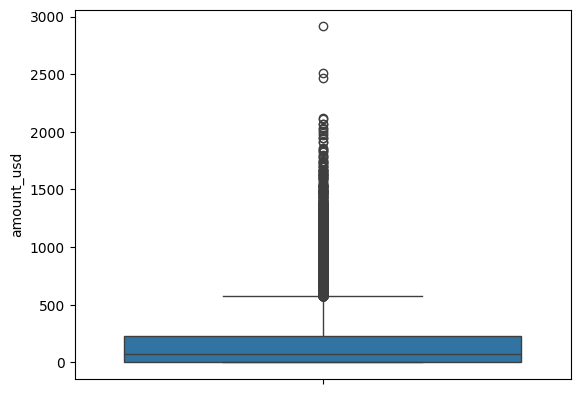

In [108]:
sns.boxplot(df_copy['amount_usd'])

**Based on the boxplot the max value of majority of transaction amount is `$500` the rest above the treshold are `outliers`**

In [109]:

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48495 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     48495 non-null  object 
 1   user_id            48495 non-null  object 
 2   amount             48495 non-null  float64
 3   currency           48495 non-null  object 
 4   merchant_id        48495 non-null  object 
 5   timestamp          48495 non-null  object 
 6   device_id          48495 non-null  object 
 7   device_type        48495 non-null  object 
 8   ip_address         48495 non-null  object 
 9   country            48495 non-null  object 
 10  chargeback_date    48495 non-null  object 
 11  chargeback_amount  48495 non-null  float64
 12  is_fraud           48495 non-null  float64
 13  is_chargeback      48495 non-null  int64  
 14  amount_usd         48495 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 5.9+ MB


In [110]:
df_copy=df_copy.drop(columns=['merchant_id','chargeback_date','amount','currency'])

In [111]:
df_copy.head()

,transaction_id,user_id,timestamp,device_id,device_type,ip_address,country,chargeback_amount,is_fraud,is_chargeback,amount_usd
0,TXN100000,USER4174,2024-04-07 14:22:06,D15795,tablet,192.168.191.91,IN,0.0,0.0,0,89.44
1,TXN100001,USER4507,2024-03-12 01:37:39,D860,mobile,192.168.38.95,US,0.0,0.0,0,111.42
2,TXN100002,USER1860,2024-01-22 08:04:34,D38158,desktop,192.168.66.194,US,0.0,0.0,0,130.20
3,TXN100003,USER2294,2024-01-30 13:02:58,D11284,mobile,192.168.167.230,IN,0.0,0.0,0,0.03
4,TXN100004,USER2130,2024-02-22 15:37:38,D6265,desktop,192.168.212.160,IN,0.0,0.0,0,0.54


In [112]:
df_copy.head()

,transaction_id,user_id,timestamp,device_id,device_type,ip_address,country,chargeback_amount,is_fraud,is_chargeback,amount_usd
0,TXN100000,USER4174,2024-04-07 14:22:06,D15795,tablet,192.168.191.91,IN,0.0,0.0,0,89.44
1,TXN100001,USER4507,2024-03-12 01:37:39,D860,mobile,192.168.38.95,US,0.0,0.0,0,111.42
2,TXN100002,USER1860,2024-01-22 08:04:34,D38158,desktop,192.168.66.194,US,0.0,0.0,0,130.20
3,TXN100003,USER2294,2024-01-30 13:02:58,D11284,mobile,192.168.167.230,IN,0.0,0.0,0,0.03
4,TXN100004,USER2130,2024-02-22 15:37:38,D6265,desktop,192.168.212.160,IN,0.0,0.0,0,0.54


In [113]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48495 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     48495 non-null  object 
 1   user_id            48495 non-null  object 
 2   timestamp          48495 non-null  object 
 3   device_id          48495 non-null  object 
 4   device_type        48495 non-null  object 
 5   ip_address         48495 non-null  object 
 6   country            48495 non-null  object 
 7   chargeback_amount  48495 non-null  float64
 8   is_fraud           48495 non-null  float64
 9   is_chargeback      48495 non-null  int64  
 10  amount_usd         48495 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 4.4+ MB


**Aggregating  devices used for transactions(users)**

In [114]:
df_copy=df_copy.sort_values(by=['user_id','timestamp'])
device_agg=df_copy.groupby('device_id').agg({
    'transaction_id': 'count',
    'user_id': 'nunique' #count of unique values for user_id
}).sort_values(by='user_id')
device_agg

,transaction_id,user_id
device_id,,
D9973,1,1
D9974,1,1
D9975,1,1
D9978,1,1
D9979,1,1
...,...,...
D24660,7,7
D9476,7,7
D21164,7,7


In [115]:
df_copy['transactions_per_device']=df_copy['device_id'].map(device_agg['user_id'])

In [116]:
df_copy.sort_values(by='transactions_per_device',ascending=False)

,transaction_id,user_id,timestamp,device_id,device_type,ip_address,country,chargeback_amount,is_fraud,is_chargeback,amount_usd,transactions_per_device
2994,TXN102994,USER4530,2024-04-19 19:42:59,D645,desktop,192.168.5.144,NG,0.00,0.0,0,2.97,8
40198,TXN140198,USER2847,2024-03-05 07:31:06,D645,mobile,192.168.142.142,KE,0.00,0.0,0,1.33,8
43628,TXN143628,USER4681,2024-04-09 20:26:06,D645,desktop,192.168.46.246,KE,0.00,0.0,0,351.46,8
35590,TXN135590,USER1240,2024-04-25 04:44:49,D645,desktop,192.168.200.206,NG,0.00,0.0,0,0.73,8
45809,TXN145809,USER4261,2024-04-16 02:56:59,D645,tablet,192.168.59.7,KE,0.00,0.0,0,395.88,8
...,...,...,...,...,...,...,...,...,...,...,...,...
42277,TXN142277,USER1001,2024-02-27 10:57:48,D40588,tablet,192.168.71.15,US,0.00,0.0,0,118.88,1
2674,TXN102674,USER1001,2024-04-11 20:49:37,D13109,desktop,192.168.65.195,US,0.00,0.0,0,28.80,1
17937,TXN117937,USER1002,2024-03-06 14:00:35,D34553,mobile,192.168.171.237,IN,53.23,1.0,1,1.98,1
31092,TXN131092,USER1003,2024-02-01 11:38:49,D3014,desktop,192.168.44.144,NG,0.00,0.0,0,77.86,1


**Aggregating: Unique ip Addresses per transactions**

In [117]:
ip_agg_user=df_copy.groupby('ip_address').agg({
    'user_id': 'nunique',
})

In [118]:
ip_agg_user

,user_id
ip_address,
192.168.0.0,1
192.168.0.10,1
192.168.0.101,1
192.168.0.102,1
192.168.0.105,1
...,...
192.168.99.91,1
192.168.99.94,1
192.168.99.96,1


In [119]:
df_copy['ip_transactions']=df_copy['ip_address'].map(ip_agg_user['user_id'])

In [120]:
df_copy.head()

,transaction_id,user_id,timestamp,device_id,device_type,ip_address,country,chargeback_amount,is_fraud,is_chargeback,amount_usd,transactions_per_device,ip_transactions
29418,TXN129418,USER1000,2024-01-09 09:53:43,D27048,mobile,192.168.156.51,GB,0.0,0.0,0,212.31,4,1
4523,TXN104523,USER1000,2024-01-09 22:21:00,D44589,tablet,192.168.45.60,KE,0.0,0.0,0,110.46,1,3
22242,TXN122242,USER1000,2024-01-21 11:24:52,D28239,tablet,192.168.176.54,NG,0.0,0.0,0,65.37,1,1
38443,TXN138443,USER1000,2024-01-26 15:39:49,D41448,desktop,192.168.177.136,GB,0.0,0.0,0,197.63,2,2
24108,TXN124108,USER1000,2024-02-07 09:03:07,D37203,mobile,192.168.145.178,KE,0.0,1.0,0,107.30,2,2


**Aggregating timestamp transactions**

In [121]:
df_copy['timestamp']=pd.to_datetime( df_copy['timestamp'] )

In [122]:
#Engineering time features...

df_copy['transaction_mth']=df_copy['timestamp'].dt.month
df_copy['transaction_wk']=df_copy['timestamp'].dt.isocalendar().week
df_copy['transaction_dy']=df_copy['timestamp'].dt.day
df_copy['transaction_hr']=df_copy['timestamp'].dt.hour
df_copy['transaction_min']=df_copy['timestamp'].dt.minute
df_copy['transaction_sec']=df_copy['timestamp'].dt.second

In [123]:
df_copy['timestamp_min']=df_copy['timestamp'].dt.floor('min') # rounding timestamp to nearest minute
df_copy['timestamp_hour']=df_copy['timestamp'].dt.floor('h') # rounding timestamp to nearest hour
df_copy['timestamp_day']=df_copy['timestamp'].dt.floor('D') # rounding timestamp to nearest day

df_copy['timestamp_week']=df_copy['timestamp'].dt.to_period('W').dt.to_timestamp() # rounding timestamp to nearest week

df_copy['timestamp_month']=df_copy['timestamp'].dt.to_period('M').dt.to_timestamp() # rounding timestamp to nearest month

In [124]:
time_min_trans_agg=df_copy.groupby('timestamp_min').agg({
    'transaction_id': 'count'
})

In [125]:
time_min_trans_agg.sort_values(by='transaction_id',ascending=False)

,transaction_id
timestamp_min,
2024-01-22 18:12:00,4
2024-01-19 13:36:00,4
2024-03-11 08:13:00,4
2024-02-14 18:29:00,4
2024-01-11 23:33:00,4
...,...
2024-02-11 17:51:00,1
2024-02-11 17:56:00,1
2024-02-11 18:00:00,1


In [126]:
df_copy['transactions_min']=df_copy['timestamp_min'].map(time_min_trans_agg['transaction_id'])

In [127]:
time_hr_trans_agg=df_copy.groupby('timestamp_hour').agg({
    'transaction_id': 'count'
})
df_copy['transactions_hour']=df_copy['timestamp_hour'].map(time_hr_trans_agg['transaction_id'])

time_hr_trans_agg

,transaction_id
timestamp_hour,
2024-01-01 00:00:00,21
2024-01-01 01:00:00,20
2024-01-01 02:00:00,17
2024-01-01 03:00:00,12
2024-01-01 04:00:00,19
...,...
2024-04-25 13:00:00,25
2024-04-25 14:00:00,25
2024-04-25 15:00:00,13


In [128]:
time_day_trans_agg=df_copy.groupby('timestamp_day').agg({
    'transaction_id': 'count'
})
df_copy['transactions_day']=df_copy['timestamp_day'].map(time_day_trans_agg['transaction_id'])
time_day_trans_agg

,transaction_id
timestamp_day,
2024-01-01,402
2024-01-02,392
2024-01-03,392
2024-01-04,415
2024-01-05,398
...,...
2024-04-21,411
2024-04-22,482
2024-04-23,427


In [129]:
time_week_trans_agg=df_copy.groupby('timestamp_week').agg({
    'transaction_id': 'count'
})
df_copy['transactions_week']=df_copy['timestamp_week'].map(time_week_trans_agg['transaction_id'])
time_week_trans_agg

,transaction_id
timestamp_week,
2024-01-01,2825
2024-01-08,2948
2024-01-15,2913
2024-01-22,2940
2024-01-29,2812
2024-02-05,2982
2024-02-12,2908
2024-02-19,2949
2024-02-26,2999


In [130]:
time_month_trans_agg=df_copy.groupby('timestamp_month').agg({
    'transaction_id': 'count'
})
df_copy['transactions_month']=df_copy['timestamp_month'].map(time_month_trans_agg['transaction_id'])
time_month_trans_agg

,transaction_id
timestamp_month,
2024-01-01,12840
2024-02-01,12153
2024-03-01,13030
2024-04-01,10472


In [131]:
df_copy.head()

,transaction_id,user_id,timestamp,device_id,device_type,ip_address,country,chargeback_amount,is_fraud,is_chargeback,...,timestamp_min,timestamp_hour,timestamp_day,timestamp_week,timestamp_month,transactions_min,transactions_hour,transactions_day,transactions_week,transactions_month
29418,TXN129418,USER1000,2024-01-09 09:53:43,D27048,mobile,192.168.156.51,GB,0.0,0.0,0,...,2024-01-09 09:53:00,2024-01-09 09:00:00,2024-01-09,2024-01-08,2024-01-01,2,19,431,2948,12840
4523,TXN104523,USER1000,2024-01-09 22:21:00,D44589,tablet,192.168.45.60,KE,0.0,0.0,0,...,2024-01-09 22:21:00,2024-01-09 22:00:00,2024-01-09,2024-01-08,2024-01-01,2,21,431,2948,12840
22242,TXN122242,USER1000,2024-01-21 11:24:52,D28239,tablet,192.168.176.54,NG,0.0,0.0,0,...,2024-01-21 11:24:00,2024-01-21 11:00:00,2024-01-21,2024-01-15,2024-01-01,1,21,443,2913,12840
38443,TXN138443,USER1000,2024-01-26 15:39:49,D41448,desktop,192.168.177.136,GB,0.0,0.0,0,...,2024-01-26 15:39:00,2024-01-26 15:00:00,2024-01-26,2024-01-22,2024-01-01,1,19,413,2940,12840
24108,TXN124108,USER1000,2024-02-07 09:03:07,D37203,mobile,192.168.145.178,KE,0.0,1.0,0,...,2024-02-07 09:03:00,2024-02-07 09:00:00,2024-02-07,2024-02-05,2024-02-01,1,21,414,2982,12153


In [132]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48495 entries, 29418 to 33314
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           48495 non-null  object        
 1   user_id                  48495 non-null  object        
 2   timestamp                48495 non-null  datetime64[ns]
 3   device_id                48495 non-null  object        
 4   device_type              48495 non-null  object        
 5   ip_address               48495 non-null  object        
 6   country                  48495 non-null  object        
 7   chargeback_amount        48495 non-null  float64       
 8   is_fraud                 48495 non-null  float64       
 9   is_chargeback            48495 non-null  int64         
 10  amount_usd               48495 non-null  float64       
 11  transactions_per_device  48495 non-null  int64         
 12  ip_transactions          48495 no

In [133]:
#Exporting this data as is to be used for visualization and analysis
df_copy.to_csv('data_before_training.csv')

In [64]:
df_copy=df_copy.drop(columns=['transaction_id','user_id','device_id','ip_address','timestamp','timestamp_min','timestamp_hour','timestamp_day','timestamp_week','timestamp_month'])

In [65]:
df_copy.head()

,device_type,country,chargeback_amount,is_fraud,is_chargeback,amount_usd,transactions_per_device,ip_transactions,transaction_mth,transaction_wk,transaction_dy,transaction_hr,transaction_min,transaction_sec,transactions_min,transactions_hour,transactions_day,transactions_week,transactions_month
29418,mobile,GB,0.0,0.0,0,212.31,4,1,1,2,9,9,53,43,2,19,431,2948,12840
4523,tablet,KE,0.0,0.0,0,110.46,1,3,1,2,9,22,21,0,2,21,431,2948,12840
22242,tablet,NG,0.0,0.0,0,65.37,1,1,1,3,21,11,24,52,1,21,443,2913,12840
38443,desktop,GB,0.0,0.0,0,197.63,2,2,1,4,26,15,39,49,1,19,413,2940,12840
24108,mobile,KE,0.0,1.0,0,107.30,2,2,2,6,7,9,3,7,1,21,414,2982,12153


In [66]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48495 entries, 29418 to 33314
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   device_type              48495 non-null  object 
 1   country                  48495 non-null  object 
 2   chargeback_amount        48495 non-null  float64
 3   is_fraud                 48495 non-null  float64
 4   is_chargeback            48495 non-null  int64  
 5   amount_usd               48495 non-null  float64
 6   transactions_per_device  48495 non-null  int64  
 7   ip_transactions          48495 non-null  int64  
 8   transaction_mth          48495 non-null  int32  
 9   transaction_wk           48495 non-null  UInt32 
 10  transaction_dy           48495 non-null  int32  
 11  transaction_hr           48495 non-null  int32  
 12  transaction_min          48495 non-null  int32  
 13  transaction_sec          48495 non-null  int32  
 14  transactions_min       

In [67]:
df_copy=df_copy.drop(columns=['is_chargeback','chargeback_amount'])

In [68]:
df_copy.head()

,device_type,country,is_fraud,amount_usd,transactions_per_device,ip_transactions,transaction_mth,transaction_wk,transaction_dy,transaction_hr,transaction_min,transaction_sec,transactions_min,transactions_hour,transactions_day,transactions_week,transactions_month
29418,mobile,GB,0.0,212.31,4,1,1,2,9,9,53,43,2,19,431,2948,12840
4523,tablet,KE,0.0,110.46,1,3,1,2,9,22,21,0,2,21,431,2948,12840
22242,tablet,NG,0.0,65.37,1,1,1,3,21,11,24,52,1,21,443,2913,12840
38443,desktop,GB,0.0,197.63,2,2,1,4,26,15,39,49,1,19,413,2940,12840
24108,mobile,KE,1.0,107.30,2,2,2,6,7,9,3,7,1,21,414,2982,12153


**Resampling the data due to imbalance of the class labels**

**Modelling the data...**

In [69]:
lr=LogisticRegression()

In [70]:
df_copy['transaction_wk']=df_copy['transaction_wk'].astype(int)
x=df_copy.drop(columns=['is_fraud','country'])
y=df_copy['is_fraud']

In [71]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48495 entries, 29418 to 33314
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   device_type              48495 non-null  object 
 1   amount_usd               48495 non-null  float64
 2   transactions_per_device  48495 non-null  int64  
 3   ip_transactions          48495 non-null  int64  
 4   transaction_mth          48495 non-null  int32  
 5   transaction_wk           48495 non-null  int64  
 6   transaction_dy           48495 non-null  int32  
 7   transaction_hr           48495 non-null  int32  
 8   transaction_min          48495 non-null  int32  
 9   transaction_sec          48495 non-null  int32  
 10  transactions_min         48495 non-null  int64  
 11  transactions_hour        48495 non-null  int64  
 12  transactions_day         48495 non-null  int64  
 13  transactions_week        48495 non-null  int64  
 14  transactions_month     

In [72]:
x=pd.get_dummies(x)

In [73]:
#Resampling x and y due to class imbalance...
sm=SMOTE(random_state=42)
x_resampled,y_resampled=sm.fit_resample(x,y)

In [74]:
#splitting the data...
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.2, random_state=42)

In [75]:
#scaling the data for modelling...using StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.fit_transform(x_test)

In [76]:
#fitting,training and predict modeling..
lr.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
lr_preds=lr.predict(x_test_scaled)

In [78]:
print(classification_report(y_test,lr_preds))

              precision    recall  f1-score   support

         0.0       0.72      0.98      0.83      9005
         1.0       0.96      0.62      0.76      8849

    accuracy                           0.80     17854
   macro avg       0.84      0.80      0.79     17854
weighted avg       0.84      0.80      0.79     17854



In [79]:
prec_lr=precision_score(y_test,lr_preds)
rec_lr=recall_score(y_test,lr_preds)
f1_lr=f1_score(y_test,lr_preds)
acc_lr=accuracy_score(y_test,lr_preds)

score_lr={'Model': 'LogisticRegression','Recall': rec_lr, 'Precision': prec_lr,'F1': f1_lr,'Accuracy': acc_lr}
results=pd.DataFrame(score_lr,index=[1])

In [80]:
results

,Model,Recall,Precision,F1,Accuracy
1,LogisticRegression,0.621765,0.963741,0.755873,0.800941


In [81]:
rf=RandomForestClassifier(random_state=42)

In [82]:
rf.fit(x_train,y_train)
rf_preds=rf.predict(x_test)

In [83]:
print(classification_report(y_test,rf_preds))

              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94      9005
         1.0       0.98      0.89      0.94      8849

    accuracy                           0.94     17854
   macro avg       0.94      0.94      0.94     17854
weighted avg       0.94      0.94      0.94     17854



In [84]:
prec_rf=precision_score(y_test,rf_preds)
rec_rf=recall_score(y_test,rf_preds)
f1_rf=f1_score(y_test,rf_preds)
acc_rf=accuracy_score(y_test,rf_preds)

score_rf={'Model': 'Untuned_RandomForestClassifier','Recall': rec_rf, 'Precision': prec_rf,'F1': f1_rf,'Accuracy': acc_rf}
results_rf=pd.DataFrame(score_rf,index=[2])
results=pd.concat([results,results_rf])
results

,Model,Recall,Precision,F1,Accuracy
1,LogisticRegression,0.621765,0.963741,0.755873,0.800941
2,Untuned_RandomForestClassifier,0.891513,0.984157,0.935547,0.939117


In [85]:
xgb=XGBClassifier(random_state=42)

In [86]:
xgb.fit(x_train,y_train)
xgb_preds=xgb.predict(x_test)

In [87]:
print(classification_report(y_test,xgb_preds))

              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91      9005
         1.0       0.97      0.83      0.90      8849

    accuracy                           0.90     17854
   macro avg       0.91      0.90      0.90     17854
weighted avg       0.91      0.90      0.90     17854



In [88]:
prec_xgb=precision_score(y_test,xgb_preds)
rec_xgb=recall_score(y_test,xgb_preds)
f1_xgb=f1_score(y_test,xgb_preds)
acc_xgb=accuracy_score(y_test,xgb_preds)

score_xgb={'Model': 'Untuned_XGBClassifier','Recall': rec_xgb, 'Precision': prec_xgb,'F1': f1_xgb,'Accuracy': acc_xgb}
results_xgb=pd.DataFrame(score_xgb,index=[3])
results=pd.concat([results,results_xgb])
results

,Model,Recall,Precision,F1,Accuracy
1,LogisticRegression,0.621765,0.963741,0.755873,0.800941
2,Untuned_RandomForestClassifier,0.891513,0.984157,0.935547,0.939117
3,Untuned_XGBClassifier,0.828907,0.972554,0.895003,0.903607


In [89]:
results=results.sort_values(by='Recall',ascending=False).reset_index().drop('index',axis=1)
results

,Model,Recall,Precision,F1,Accuracy
0,Untuned_RandomForestClassifier,0.891513,0.984157,0.935547,0.939117
1,Untuned_XGBClassifier,0.828907,0.972554,0.895003,0.903607
2,LogisticRegression,0.621765,0.963741,0.755873,0.800941


In [90]:
x_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89268 entries, 0 to 89267
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   amount_usd               89268 non-null  float64
 1   transactions_per_device  89268 non-null  int64  
 2   ip_transactions          89268 non-null  int64  
 3   transaction_mth          89268 non-null  int32  
 4   transaction_wk           89268 non-null  int64  
 5   transaction_dy           89268 non-null  int32  
 6   transaction_hr           89268 non-null  int32  
 7   transaction_min          89268 non-null  int32  
 8   transaction_sec          89268 non-null  int32  
 9   transactions_min         89268 non-null  int64  
 10  transactions_hour        89268 non-null  int64  
 11  transactions_day         89268 non-null  int64  
 12  transactions_week        89268 non-null  int64  
 13  transactions_month       89268 non-null  int64  
 14  device_type_desktop   

**Therefore Untuned_RandomForestClassifier Becomes the champion model....**

In [91]:
df_copy.head()

,device_type,country,is_fraud,amount_usd,transactions_per_device,ip_transactions,transaction_mth,transaction_wk,transaction_dy,transaction_hr,transaction_min,transaction_sec,transactions_min,transactions_hour,transactions_day,transactions_week,transactions_month
29418,mobile,GB,0.0,212.31,2,1,1,2,9,9,53,43,2,19,431,2948,12840
4523,tablet,KE,0.0,110.46,2,3,1,2,9,22,21,0,2,21,431,2948,12840
22242,tablet,NG,0.0,65.37,1,1,1,3,21,11,24,52,1,21,443,2913,12840
38443,desktop,GB,0.0,197.63,3,2,1,4,26,15,39,49,1,19,413,2940,12840
24108,mobile,KE,1.0,107.30,1,2,2,6,7,9,3,7,1,21,414,2982,12153


In [92]:
df_copy.to_csv('data_used_training.csv')

In [93]:
importance=rf.feature_importances_

In [115]:
df_importance=pd.Series(data=importance,index=x.columns).sort_values(ascending=False)

In [117]:
df_importance=df_importance.reset_index()

In [123]:
df_importance=df_importance.rename(columns={'index':'features',0:'importance_score'})

In [124]:
df_importance

,features,importance_score
0,device_type_mobile,0.139660
1,device_type_desktop,0.122251
2,device_type_tablet,0.110082
3,amount_usd,0.089071
4,transaction_sec,0.070389
5,transaction_min,0.069413
6,transaction_hr,0.062465
7,transactions_day,0.059896
8,transactions_hour,0.051441
9,transaction_dy,0.050908


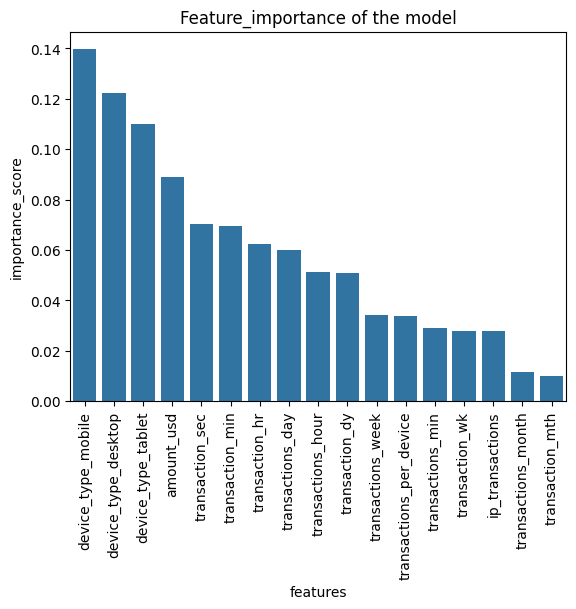

In [131]:
sns.barplot(data=df_importance,x='features',y='importance_score')
plt.title('Feature_importance of the model')
plt.xticks(rotation=90)
plt.show()

In [132]:
df_importance.to_csv('feature_importance_model.csv')

In [133]:
results.to_csv('results_models_trained.csv')